# EEG Denoising with ICA
**Dataset:** EEGDenoiseNet-style HDF5 files (7 artifact combos × 3 splits)

**Artifacts:** EMG, EOG, ECG (single and combined)

**Pipeline:**
1. Load noisy/clean EEG from `.h5` files
2. Apply FastICA to separate artifact components
3. Identify and zero-out artifact ICs via kurtosis / autocorrelation heuristics
4. Reconstruct denoised EEG
5. Evaluate: MSE, SNR improvement, **Spectral Loss** (frequency-domain MSE)
6. Visualise results

## 1 · Install & Import

In [14]:
%%capture
!pip install h5py scikit-learn scipy numpy matplotlib tqdm

In [15]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal as sp_signal
from sklearn.decomposition import FastICA
from tqdm.notebook import tqdm

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('All imports OK')

All imports OK


## 2 · Configuration

In [16]:
# ── Dataset ────────────────────────────────────────────────────────────────
# Kaggle input path — adjust to your dataset slug
DATA_DIR    = '/kaggle/input/datasets/lucky3663/eegdenoise'   # <── change to your dataset path
RESULTS_DIR = '/kaggle/working/ica_results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Signal ─────────────────────────────────────────────────────────────────
FS       = 256   # Hz
SEG_LEN  = 512   # samples per segment (2 s @ 256 Hz)

# ── ICA ────────────────────────────────────────────────────────────────────
N_COMPONENTS     = 16      # ICA components (<=SEG_LEN; trade-off speed/quality)
ICA_MAX_ITER     = 1000
ICA_TOL          = 1e-4
ICA_RANDOM_STATE = 42

# Artifact rejection thresholds
KURTOSIS_THRESH = 3.0   # |excess kurtosis| > thresh -> flag as artifact IC
AUTOCORR_THRESH = 0.3   # lag-1 autocorr < thresh   -> flag as high-freq noise

# ── Evaluation ─────────────────────────────────────────────────────────────
EVAL_SPLIT  = 'test'   # train / val / test
MAX_SAMPLES = None     # cap for speed on Kaggle free tier (None = all)

COMBOS = ['emg', 'eog', 'ecg', 'emg_eog', 'emg_ecg', 'eog_ecg', 'emg_eog_ecg']

print(f'Data dir   : {DATA_DIR}')
print(f'Results dir: {RESULTS_DIR}')
print(f'Combos     : {COMBOS}')

Data dir   : /kaggle/input/datasets/lucky3663/eegdenoise
Results dir: /kaggle/working/ica_results
Combos     : ['emg', 'eog', 'ecg', 'emg_eog', 'emg_ecg', 'eog_ecg', 'emg_eog_ecg']


## 3 · Data Loader

In [17]:
def load_h5(combo, split, max_samples=None):
    """Load clean/noisy arrays from {combo}_{split}.h5.
    Returns (clean, noisy) as float32 arrays of shape (N, 512).
    """
    path = os.path.join(DATA_DIR, f'{combo}_{split}.h5')
    if not os.path.exists(path):
        raise FileNotFoundError(f'File not found: {path}')
    with h5py.File(path, 'r') as f:
        clean = f['clean'][:max_samples].astype(np.float32)
        noisy = f['noisy'][:max_samples].astype(np.float32)
    return clean, noisy


def list_available_files(data_dir):
    """Print all .h5 files found in data_dir."""
    files = sorted(glob.glob(os.path.join(data_dir, '*.h5')))
    if not files:
        print('WARNING: No .h5 files found. Check DATA_DIR.')
    else:
        print(f'Found {len(files)} .h5 files:')
        for f in files:
            sz = os.path.getsize(f) / 1e6
            print(f'  {os.path.basename(f):30s}  {sz:6.1f} MB')
    return files


list_available_files(DATA_DIR)

Found 21 .h5 files:
  ecg_test.h5                       17.1 MB
  ecg_train.h5                     136.5 MB
  ecg_val.h5                        17.1 MB
  emg_ecg_test.h5                   17.2 MB
  emg_ecg_train.h5                 137.1 MB
  emg_ecg_val.h5                    17.1 MB
  emg_eog_ecg_test.h5               17.2 MB
  emg_eog_ecg_train.h5             137.3 MB
  emg_eog_ecg_val.h5                17.2 MB
  emg_eog_test.h5                   17.2 MB
  emg_eog_train.h5                 137.6 MB
  emg_eog_val.h5                    17.2 MB
  emg_test.h5                       17.2 MB
  emg_train.h5                     137.6 MB
  emg_val.h5                        17.2 MB
  eog_ecg_test.h5                   17.2 MB
  eog_ecg_train.h5                 137.0 MB
  eog_ecg_val.h5                    17.1 MB
  eog_test.h5                       17.2 MB
  eog_train.h5                     137.7 MB
  eog_val.h5                        17.2 MB


['/kaggle/input/datasets/lucky3663/eegdenoise/ecg_test.h5',
 '/kaggle/input/datasets/lucky3663/eegdenoise/ecg_train.h5',
 '/kaggle/input/datasets/lucky3663/eegdenoise/ecg_val.h5',
 '/kaggle/input/datasets/lucky3663/eegdenoise/emg_ecg_test.h5',
 '/kaggle/input/datasets/lucky3663/eegdenoise/emg_ecg_train.h5',
 '/kaggle/input/datasets/lucky3663/eegdenoise/emg_ecg_val.h5',
 '/kaggle/input/datasets/lucky3663/eegdenoise/emg_eog_ecg_test.h5',
 '/kaggle/input/datasets/lucky3663/eegdenoise/emg_eog_ecg_train.h5',
 '/kaggle/input/datasets/lucky3663/eegdenoise/emg_eog_ecg_val.h5',
 '/kaggle/input/datasets/lucky3663/eegdenoise/emg_eog_test.h5',
 '/kaggle/input/datasets/lucky3663/eegdenoise/emg_eog_train.h5',
 '/kaggle/input/datasets/lucky3663/eegdenoise/emg_eog_val.h5',
 '/kaggle/input/datasets/lucky3663/eegdenoise/emg_test.h5',
 '/kaggle/input/datasets/lucky3663/eegdenoise/emg_train.h5',
 '/kaggle/input/datasets/lucky3663/eegdenoise/emg_val.h5',
 '/kaggle/input/datasets/lucky3663/eegdenoise/eog_ec

## 4 · Metric Functions

In [18]:
# ── Time-domain metrics ────────────────────────────────────────────────────

def mse(clean, pred):
    """Mean squared error (averaged over all samples and time steps)."""
    return float(np.mean((clean - pred) ** 2))


def snr_improvement(clean, noisy, denoised):
    """Average per-segment SNR improvement (dB).
    dSNR = SNR_denoised - SNR_input
    SNR  = 10 * log10( ||clean||^2 / ||residual||^2 )
    """
    eps = 1e-12
    sig_pow   = np.sum(clean ** 2, axis=1) + eps
    noise_in  = np.sum((noisy    - clean) ** 2, axis=1) + eps
    noise_out = np.sum((denoised - clean) ** 2, axis=1) + eps
    snr_in    = 10 * np.log10(sig_pow / noise_in)
    snr_out   = 10 * np.log10(sig_pow / noise_out)
    return float(np.mean(snr_out - snr_in))


def rrmse(clean, pred):
    """Relative RMSE normalised by RMS of clean signal."""
    eps = 1e-12
    num = np.sqrt(np.mean((clean - pred) ** 2, axis=1))
    den = np.sqrt(np.mean(clean ** 2, axis=1)) + eps
    return float(np.mean(num / den))


# ── Spectral (frequency-domain) loss ──────────────────────────────────────

def spectral_loss(clean, pred, fs=FS, log_scale=True):
    """Spectral MSE between clean and predicted signal.

    Computes the MSE between magnitude spectra (optionally log-compressed).
    This penalises errors concentrated in specific frequency bands.

    Args:
        clean      : (N, T) ground-truth EEG
        pred       : (N, T) denoised EEG
        fs         : sampling rate in Hz
        log_scale  : if True, compare log(1 + |X|) spectra (perceptual)

    Returns:
        Scalar spectral loss (mean over all segments and frequency bins).
    """
    S_clean = np.abs(np.fft.rfft(clean, axis=1))
    S_pred  = np.abs(np.fft.rfft(pred,  axis=1))
    if log_scale:
        S_clean = np.log1p(S_clean)
        S_pred  = np.log1p(S_pred)
    return float(np.mean((S_clean - S_pred) ** 2))


def spectral_loss_per_band(clean, pred, fs=FS):
    """Spectral MSE broken down into EEG frequency bands.

    Bands (Hz): delta 0.5-4, theta 4-8, alpha 8-13,
                beta 13-30, gamma 30-45, high 45-128
    """
    bands = {
        'delta': (0.5,  4),
        'theta': (4,    8),
        'alpha': (8,   13),
        'beta' : (13,  30),
        'gamma': (30,  45),
        'high' : (45, 128),
    }
    freqs   = np.fft.rfftfreq(clean.shape[1], d=1/fs)
    S_clean = np.abs(np.fft.rfft(clean, axis=1))
    S_pred  = np.abs(np.fft.rfft(pred,  axis=1))

    result = {}
    for band, (lo, hi) in bands.items():
        mask = (freqs >= lo) & (freqs < hi)
        if mask.sum() == 0:
            result[band] = float('nan')
        else:
            diff = S_clean[:, mask] - S_pred[:, mask]
            result[band] = float(np.mean(diff ** 2))
    return result


def evaluate(clean, noisy, denoised, tag=''):
    """Compute and print all metrics; return a dict."""
    m = {
        'mse_noisy'             : mse(clean, noisy),
        'mse_denoised'          : mse(clean, denoised),
        'rrmse_noisy'           : rrmse(clean, noisy),
        'rrmse_denoised'        : rrmse(clean, denoised),
        'snr_improvement_db'    : snr_improvement(clean, noisy, denoised),
        'spectral_loss_noisy'   : spectral_loss(clean, noisy),
        'spectral_loss_denoised': spectral_loss(clean, denoised),
        'band_spectral_loss'    : spectral_loss_per_band(clean, denoised),
    }
    lbl = f'[{tag}] ' if tag else ''
    print(f'{lbl}MSE          noisy={m["mse_noisy"]:.5f}  denoised={m["mse_denoised"]:.5f}')
    print(f'{lbl}RRMSE        noisy={m["rrmse_noisy"]:.4f}   denoised={m["rrmse_denoised"]:.4f}')
    print(f'{lbl}SNR improvement: {m["snr_improvement_db"]:+.3f} dB')
    print(f'{lbl}Spectral loss  noisy={m["spectral_loss_noisy"]:.5f}  denoised={m["spectral_loss_denoised"]:.5f}')
    print(f'{lbl}Band spectral loss:')
    for b, v in m['band_spectral_loss'].items():
        print(f'      {b:6s}: {v:.5f}')
    return m

print('Metric functions defined')

Metric functions defined


## 5 · ICA Denoiser

In [19]:
def _kurtosis(x):
    """Excess kurtosis (Fisher, 0 for Gaussian) along axis=1."""
    mu  = x.mean(axis=1, keepdims=True)
    std = x.std(axis=1,  keepdims=True) + 1e-12
    return np.mean(((x - mu) / std) ** 4, axis=1) - 3


def _lag1_autocorr(x):
    """Lag-1 autocorrelation for each row of x."""
    x_c = x - x.mean(axis=1, keepdims=True)
    num = np.sum(x_c[:, :-1] * x_c[:, 1:], axis=1)
    den = np.sum(x_c ** 2, axis=1) + 1e-12
    return num / den


class ICADenoiser:
    """Single-channel ICA denoiser for EEG segments.

    Strategy
    --------
    Each 1-D segment of length T is reshaped into a pseudo-multichannel
    matrix of shape (T // n_components, n_components). FastICA then
    extracts n_components independent components (ICs). Artifact ICs are
    identified by two heuristics and zeroed before back-projection:

      1. |excess kurtosis| > kurtosis_thresh  -> non-Gaussian  -> artifact
      2. lag-1 autocorr   < autocorr_thresh   -> high-freq noise (EMG-like)

    At least one IC is always preserved to prevent returning a zero signal.
    """

    def __init__(self,
                 n_components=N_COMPONENTS,
                 kurtosis_thresh=KURTOSIS_THRESH,
                 autocorr_thresh=AUTOCORR_THRESH,
                 max_iter=ICA_MAX_ITER,
                 tol=ICA_TOL,
                 random_state=ICA_RANDOM_STATE):
        self.n_components    = n_components
        self.kurtosis_thresh = kurtosis_thresh
        self.autocorr_thresh = autocorr_thresh
        self.ica = FastICA(
            n_components = n_components,
            max_iter     = max_iter,
            tol          = tol,
            random_state = random_state,
            whiten       = 'unit-variance',
        )

    def _denoise_segment(self, seg):
        """Denoise a single 1-D segment (shape: T,)."""
        T  = len(seg)
        nc = self.n_components

        # Reshape into pseudo-channels: (T//nc, nc)
        T_trim = (T // nc) * nc
        x_mat  = seg[:T_trim].reshape(nc, T // nc).T

        try:
            S = self.ica.fit_transform(x_mat)   # (T//nc, nc) sources
            A = self.ica.mixing_                # (nc, nc) mixing matrix
        except Exception:
            return seg.copy()   # ICA failed -> return original unchanged

        # ── Artifact identification ────────────────────────────────────────
        kurt_vals = np.abs(_kurtosis(S.T))    # shape (nc,)
        ac_vals   = _lag1_autocorr(S.T)       # shape (nc,)

        artifact_mask = (
            (kurt_vals > self.kurtosis_thresh) |
            (ac_vals   < self.autocorr_thresh)
        )

        # Always keep the component with lowest kurtosis
        if artifact_mask.all():
            artifact_mask[np.argmin(kurt_vals)] = False

        # ── Reconstruct without artifact ICs ──────────────────────────────
        S_clean = S.copy()
        S_clean[:, artifact_mask] = 0.0

        x_rec     = S_clean @ A.T
        x_rec    += x_mat.mean(axis=0)   # restore DC offset

        out          = seg.copy()
        out[:T_trim] = x_rec.T.flatten()
        return out

    def denoise_batch(self, noisy, show_progress=True):
        """Denoise a batch of segments.

        Parameters
        ----------
        noisy : ndarray of shape (N, T), float32

        Returns
        -------
        denoised : ndarray of shape (N, T), float32
        """
        N        = len(noisy)
        denoised = np.empty_like(noisy)

        iterator = (
            tqdm(range(N), desc='  ICA denoising', unit='seg', leave=False)
            if show_progress else range(N)
        )
        for i in iterator:
            denoised[i] = self._denoise_segment(noisy[i])

        return denoised


print('ICADenoiser class defined')

ICADenoiser class defined


## 6 · Run ICA on All Combos

In [20]:
denoiser = ICADenoiser(
    n_components    = N_COMPONENTS,
    kurtosis_thresh = KURTOSIS_THRESH,
    autocorr_thresh = AUTOCORR_THRESH,
)

all_results = {}   # combo -> {clean, noisy, denoised, metrics}

combo_bar = tqdm(COMBOS, desc='Artifact combos', unit='combo')

for combo in combo_bar:
    combo_bar.set_postfix(combo=combo)

    # Load
    try:
        clean, noisy = load_h5(combo, EVAL_SPLIT, max_samples=MAX_SAMPLES)
    except FileNotFoundError as e:
        print(f'  SKIP {combo}: {e}')
        continue

    print(f'\n── {combo.upper():12s}  shape={noisy.shape} ──')

    # Denoise
    denoised = denoiser.denoise_batch(noisy, show_progress=True)

    # Evaluate
    metrics = evaluate(clean, noisy, denoised, tag=combo)
    all_results[combo] = {
        'clean'   : clean,
        'noisy'   : noisy,
        'denoised': denoised,
        'metrics' : metrics,
    }

print('\nAll combos processed')

Artifact combos:   0%|          | 0/7 [00:00<?, ?combo/s]


── EMG           shape=(4520, 512) ──


  ICA denoising:   0%|          | 0/4520 [00:00<?, ?seg/s]

[emg] MSE          noisy=0.70011  denoised=0.35022
[emg] RRMSE        noisy=2.1931   denoised=1.3290
[emg] SNR improvement: +3.102 dB
[emg] Spectral loss  noisy=3.30695  denoised=1.11212
[emg] Band spectral loss:
      delta : 999.80841
      theta : 282.03345
      alpha : 912.54639
      beta  : 105.20945
      gamma : 25.55034
      high  : 19.02101

── EOG           shape=(4520, 512) ──


  ICA denoising:   0%|          | 0/4520 [00:00<?, ?seg/s]

...

[emg_ecg] MSE          noisy=1.01581  denoised=0.63040
[emg_ecg] RRMSE        noisy=3.0995   denoised=2.2727
[emg_ecg] SNR improvement: +2.052 dB
[emg_ecg] Spectral loss  noisy=3.22284  denoised=1.16217
[emg_ecg] Band spectral loss:
      delta : 1633.05090
      theta : 313.01639
      alpha : 688.15179
      beta  : 83.04226
      gamma : 23.17730
      high  : 17.73521

── EOG_ECG       shape=(4520, 512) ──


  ICA denoising:   0%|          | 0/4520 [00:00<?, ?seg/s]

[eog_ecg] MSE          noisy=1.03384  denoised=0.96930
[eog_ecg] RRMSE        noisy=3.0941   denoised=2.8613
[eog_ecg] SNR improvement: +0.203 dB
[eog_ecg] Spectral loss  noisy=0.38646  denoised=0.82906
[eog_ecg] Band spectral loss:
      delta : 6006.80908
      theta : 423.61057
      alpha : 691.41272
      beta  : 87.45849
      gamma : 21.50202
      high  : 7.30343

── EMG_EOG_ECG   shape=(4520, 512) ──


  ICA denoising:   0%|          | 0/4520 [00:00<?, ?seg/s]

[emg_eog_ecg] MSE          noisy=0.99983  denoised=0.70867
[emg_eog_ecg] RRMSE        noisy=3.7774   denoised=3.0400
[emg_eog_ecg] SNR improvement: +1.476 dB
[emg_eog_ecg] Spectral loss  noisy=2.93777  denoised=1.13368
[emg_eog_ecg] Band spectral loss:
      delta : 4634.78467
      theta : 312.45096
      alpha : 469.66141
      beta  : 61.70441
      gamma : 18.60054
      high  : 14.32445

All combos processed


## 7 · Summary Table

In [21]:
import pandas as pd

rows = []
for combo, res in all_results.items():
    m = res['metrics']
    rows.append({
        'Combo'               : combo,
        'MSE (noisy)'         : f"{m['mse_noisy']:.5f}",
        'MSE (denoised)'      : f"{m['mse_denoised']:.5f}",
        'RRMSE (noisy)'       : f"{m['rrmse_noisy']:.4f}",
        'RRMSE (denoised)'    : f"{m['rrmse_denoised']:.4f}",
        'ΔSNR (dB)'           : f"{m['snr_improvement_db']:+.3f}",
        'Spec Loss (noisy)'   : f"{m['spectral_loss_noisy']:.5f}",
        'Spec Loss (denoised)': f"{m['spectral_loss_denoised']:.5f}",
    })

df_summary = pd.DataFrame(rows)
df_summary.to_csv(os.path.join(RESULTS_DIR, 'ica_summary.csv'), index=False)
print(df_summary.to_string(index=False))

      Combo MSE (noisy) MSE (denoised) RRMSE (noisy) RRMSE (denoised) ΔSNR (dB) Spec Loss (noisy) Spec Loss (denoised)
        emg     0.70011        0.35022        2.1931           1.3290    +3.102           3.30695              1.11212
        eog     0.70687        0.82302        2.1931           2.2521    -0.932           0.16968              0.78087
        ecg     1.46916        1.45792        2.1931           2.0464    -0.158           0.31818              0.86472
    emg_eog     0.80884        0.56228        3.0922           2.4320    +1.494           2.96083              1.06585
    emg_ecg     1.01581        0.63040        3.0995           2.2727    +2.052           3.22284              1.16217
    eog_ecg     1.03384        0.96930        3.0941           2.8613    +0.203           0.38646              0.82906
emg_eog_ecg     0.99983        0.70867        3.7774           3.0400    +1.476           2.93777              1.13368


## 8 · Per-Band Spectral Loss Chart

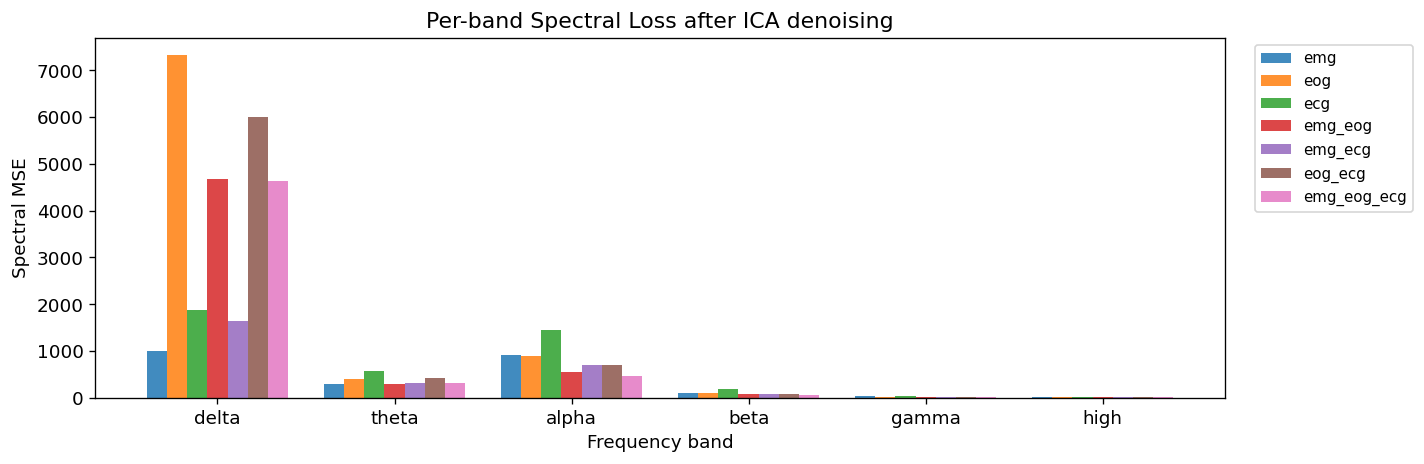

Saved -> band_spectral_loss.png


In [22]:
if not all_results:
    print('No results to plot.')
else:
    combos_done = list(all_results.keys())
    bands       = list(next(iter(all_results.values()))['metrics']['band_spectral_loss'].keys())

    data = np.array([
        [all_results[c]['metrics']['band_spectral_loss'][b] for b in bands]
        for c in combos_done
    ])

    x    = np.arange(len(bands))
    w    = 0.8 / len(combos_done)
    cmap = plt.get_cmap('tab10')

    fig, ax = plt.subplots(figsize=(12, 4))
    for i, combo in enumerate(combos_done):
        ax.bar(x + i * w, data[i], width=w, label=combo,
               color=cmap(i), alpha=0.85)

    ax.set_xticks(x + w * (len(combos_done) - 1) / 2)
    ax.set_xticklabels(bands)
    ax.set_xlabel('Frequency band')
    ax.set_ylabel('Spectral MSE')
    ax.set_title('Per-band Spectral Loss after ICA denoising')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    fig.tight_layout()
    fig.savefig(os.path.join(RESULTS_DIR, 'band_spectral_loss.png'), bbox_inches='tight')
    plt.show()
    print('Saved -> band_spectral_loss.png')

## 9 · Waveform + Spectrum — One Example Per Combo

Plotting examples:   0%|          | 0/7 [00:00<?, ?it/s]

Saved -> /kaggle/working/ica_results/example_emg.png


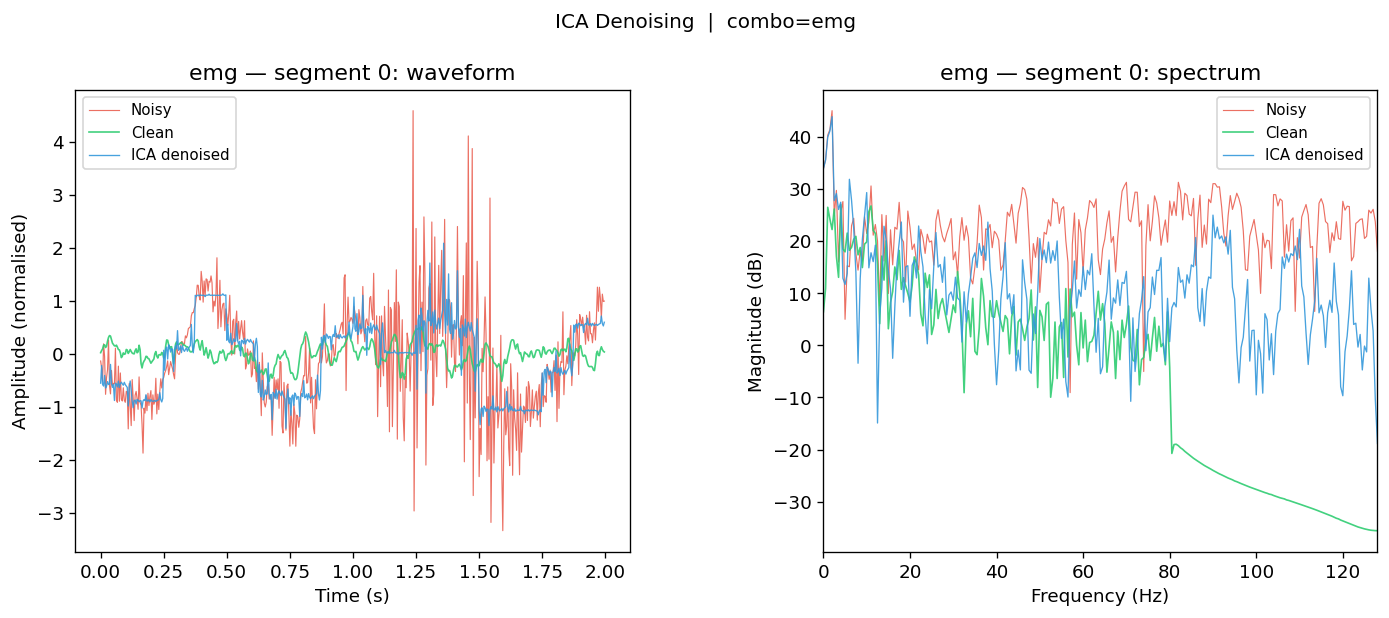

Saved -> /kaggle/working/ica_results/example_eog.png


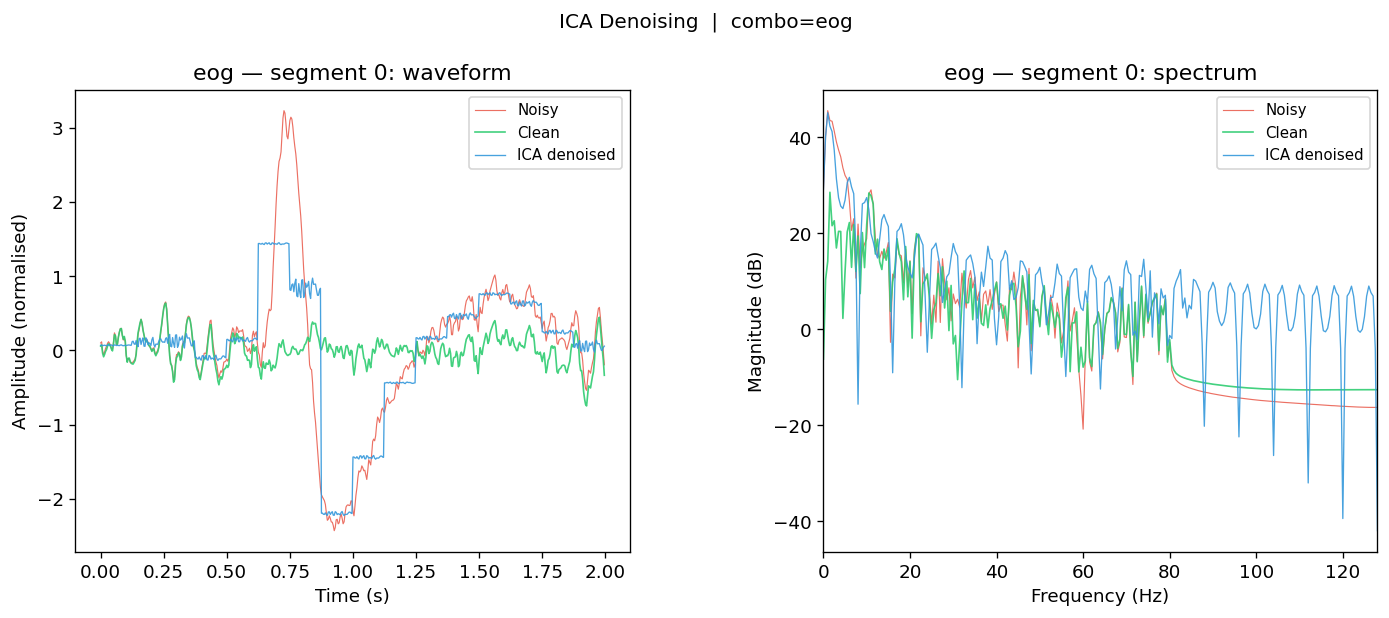

Saved -> /kaggle/working/ica_results/example_ecg.png


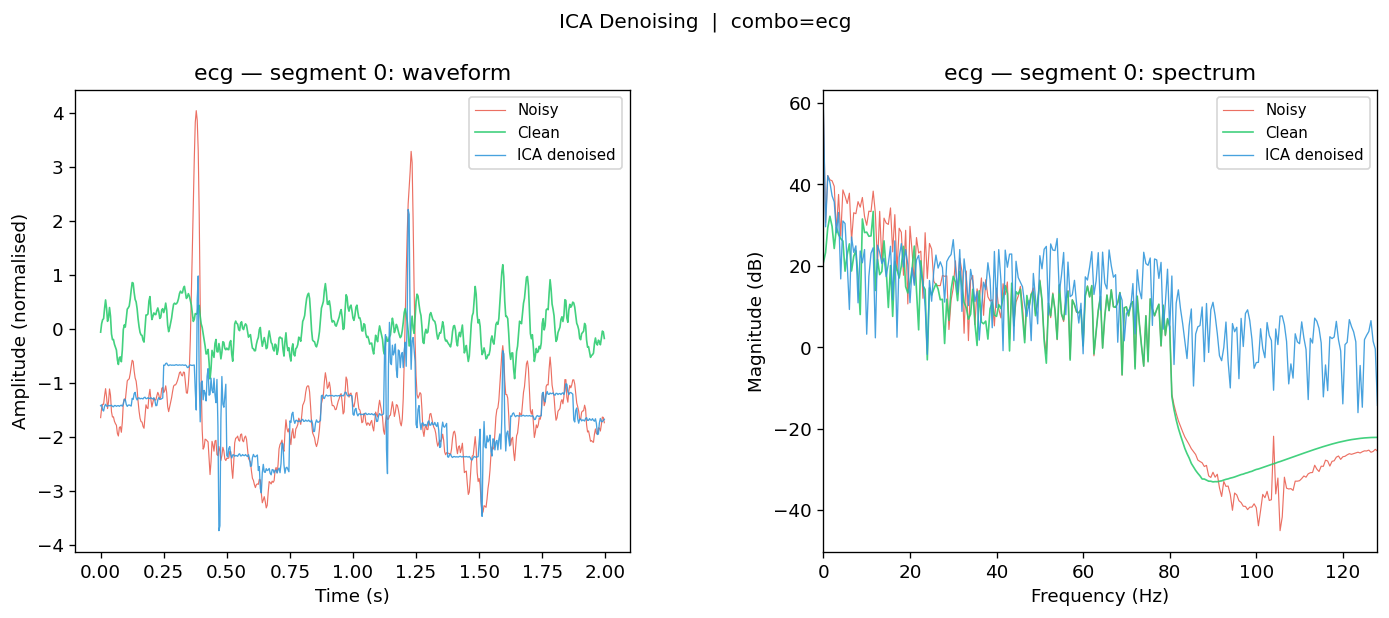

Saved -> /kaggle/working/ica_results/example_emg_eog.png


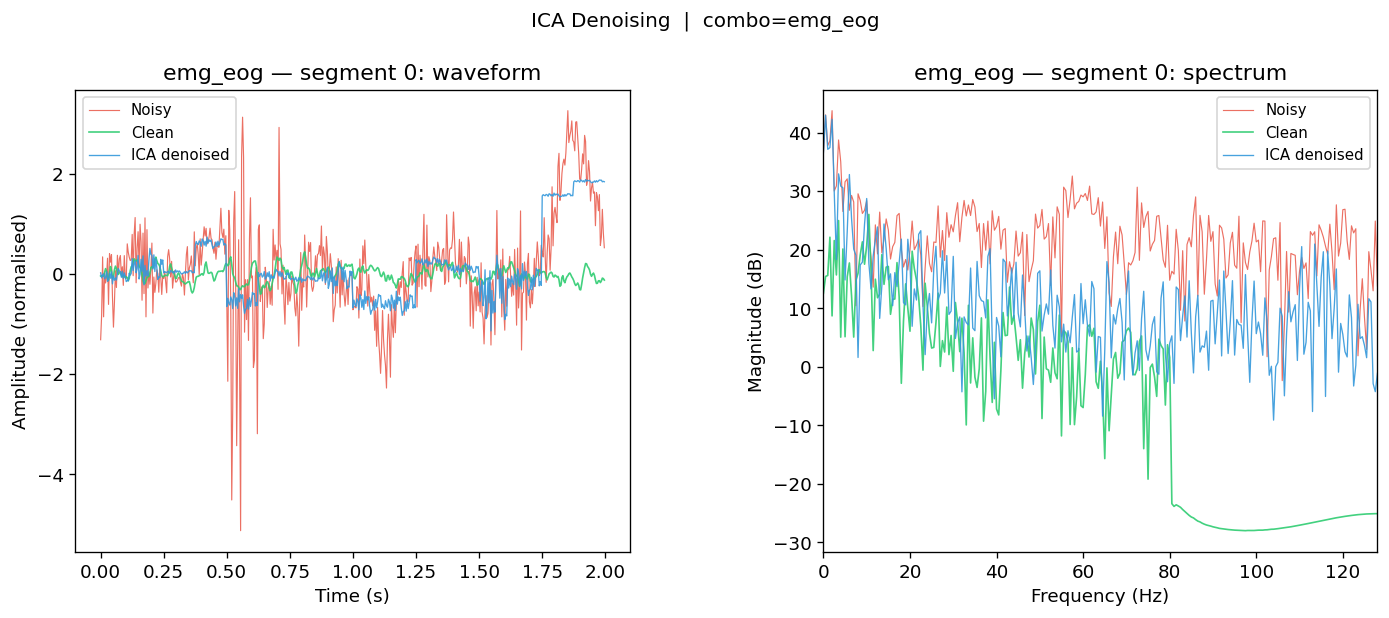

Saved -> /kaggle/working/ica_results/example_emg_ecg.png


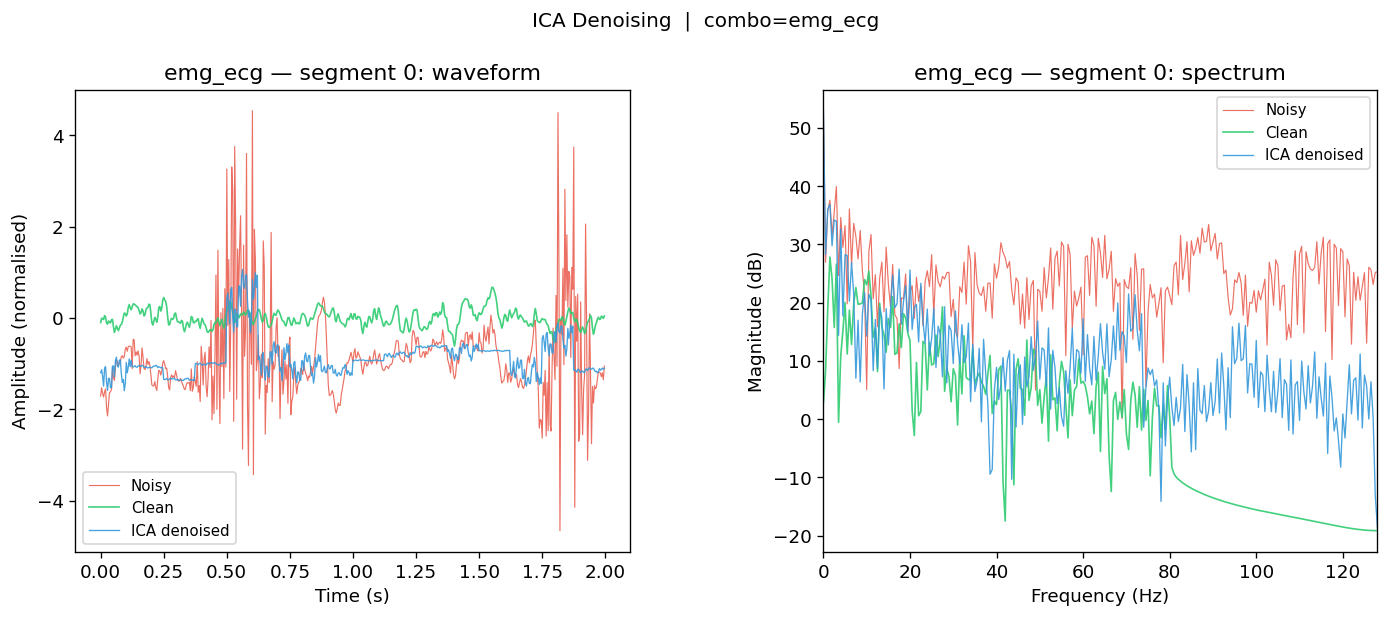

Saved -> /kaggle/working/ica_results/example_eog_ecg.png


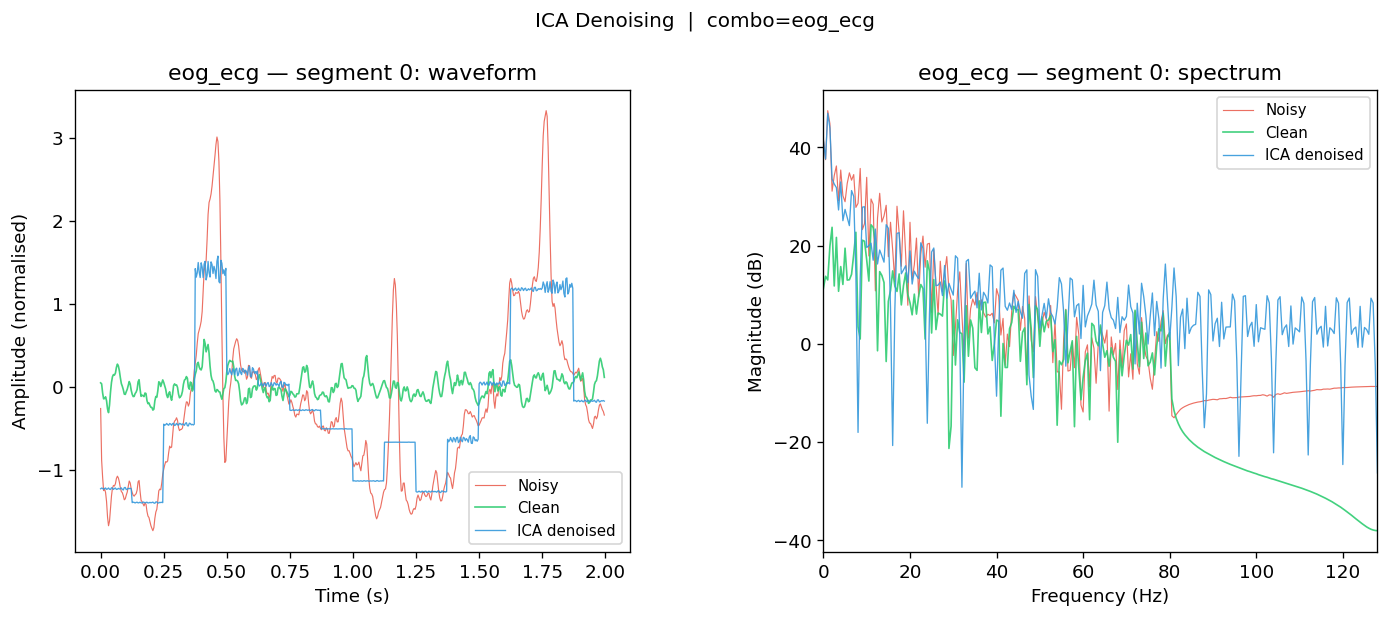

Saved -> /kaggle/working/ica_results/example_emg_eog_ecg.png


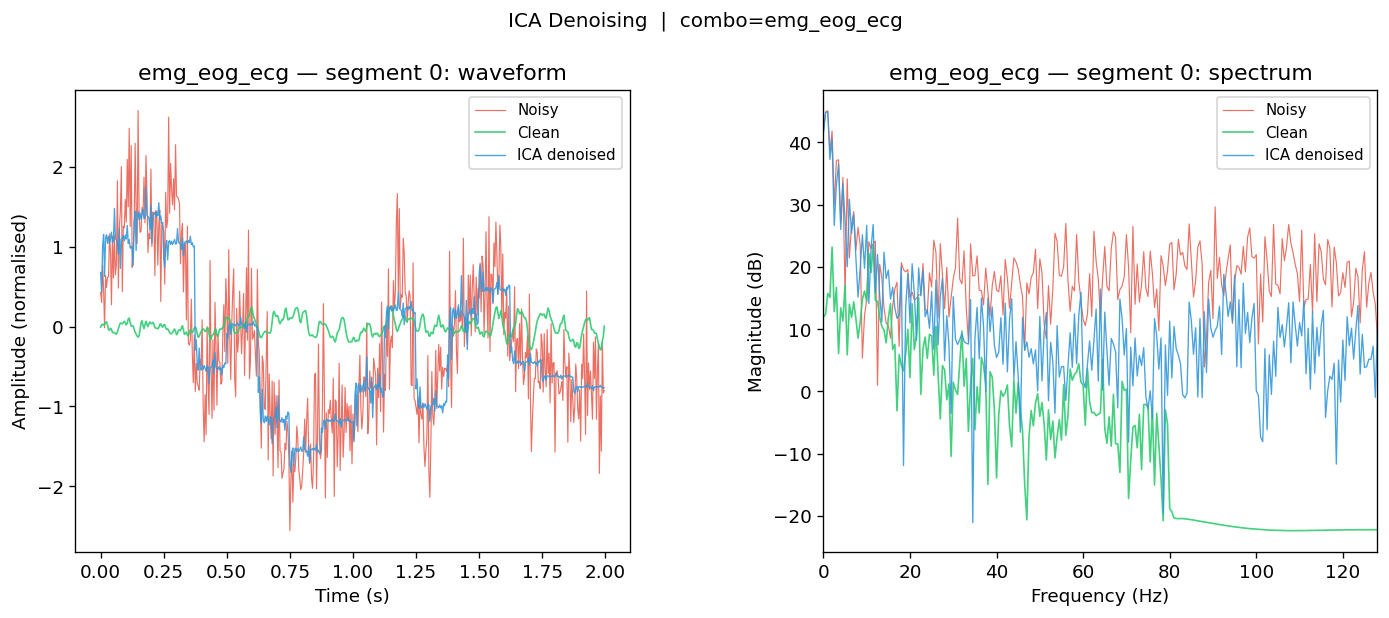

In [23]:
def plot_example(combo, idx=0, fs=FS, save_dir=None):
    """Plot clean / noisy / denoised waveform and magnitude spectrum."""
    res      = all_results[combo]
    clean    = res['clean'][idx]
    noisy    = res['noisy'][idx]
    denoised = res['denoised'][idx]

    t    = np.arange(len(clean)) / fs
    freq = np.fft.rfftfreq(len(clean), d=1/fs)

    def mag_db(x):
        return 20 * np.log10(np.abs(np.fft.rfft(x)) + 1e-12)

    fig = plt.figure(figsize=(14, 5))
    gs  = gridspec.GridSpec(1, 2, wspace=0.35)

    # Waveform
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(t, noisy,    color='#e74c3c', lw=0.7, alpha=0.8, label='Noisy')
    ax1.plot(t, clean,    color='#2ecc71', lw=1.0, alpha=0.9, label='Clean')
    ax1.plot(t, denoised, color='#3498db', lw=0.8, alpha=0.9, label='ICA denoised')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Amplitude (normalised)')
    ax1.set_title(f'{combo} — segment {idx}: waveform')
    ax1.legend(fontsize=9)

    # Spectrum
    ax2 = fig.add_subplot(gs[1])
    ax2.plot(freq, mag_db(noisy),    color='#e74c3c', lw=0.7, alpha=0.8, label='Noisy')
    ax2.plot(freq, mag_db(clean),    color='#2ecc71', lw=1.0, alpha=0.9, label='Clean')
    ax2.plot(freq, mag_db(denoised), color='#3498db', lw=0.8, alpha=0.9, label='ICA denoised')
    ax2.set_xlim(0, fs // 2)
    ax2.set_xlabel('Frequency (Hz)')
    ax2.set_ylabel('Magnitude (dB)')
    ax2.set_title(f'{combo} — segment {idx}: spectrum')
    ax2.legend(fontsize=9)

    fig.suptitle(f'ICA Denoising  |  combo={combo}', fontsize=12, y=1.01)
    fig.tight_layout()

    if save_dir:
        fname = os.path.join(save_dir, f'example_{combo}.png')
        fig.savefig(fname, bbox_inches='tight')
        print(f'Saved -> {fname}')
    plt.show()


for combo in tqdm(list(all_results.keys()), desc='Plotting examples'):
    plot_example(combo, idx=0, save_dir=RESULTS_DIR)

## 10 · Spectral Loss & SNR Summary Chart

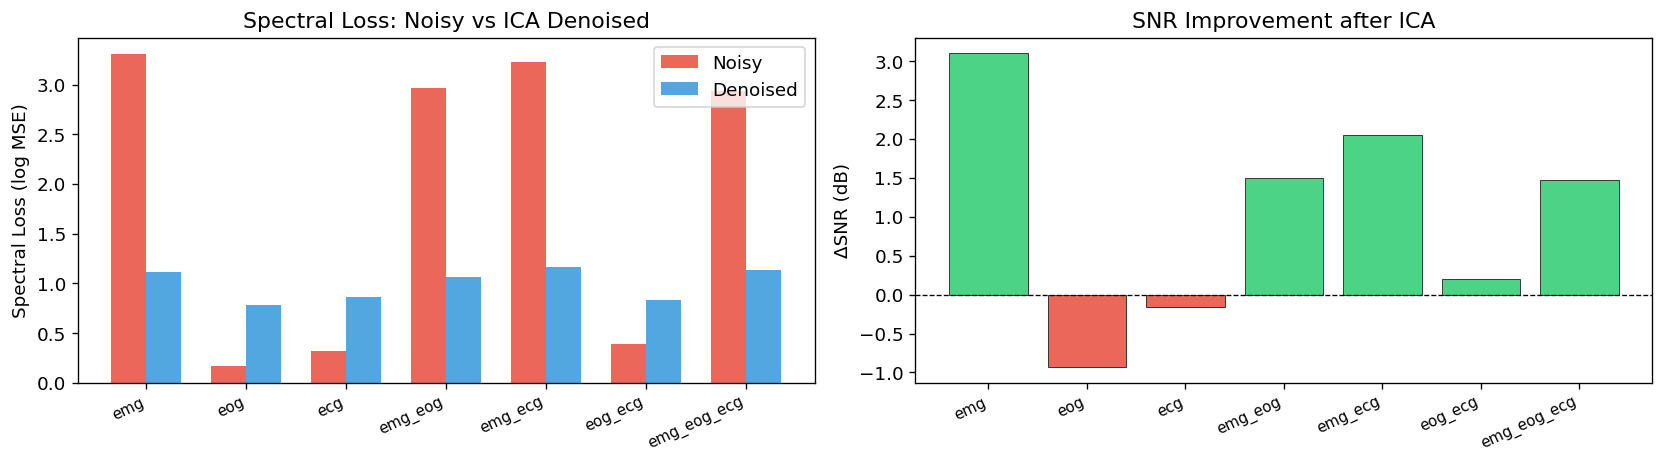

Saved -> spectral_snr_summary.png


In [24]:
if all_results:
    combos_done = list(all_results.keys())
    sl_noisy    = [all_results[c]['metrics']['spectral_loss_noisy']    for c in combos_done]
    sl_denoised = [all_results[c]['metrics']['spectral_loss_denoised'] for c in combos_done]
    snr_imp     = [all_results[c]['metrics']['snr_improvement_db']     for c in combos_done]

    x = np.arange(len(combos_done))
    w = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Spectral loss comparison
    ax = axes[0]
    ax.bar(x - w/2, sl_noisy,    w, label='Noisy',    color='#e74c3c', alpha=0.85)
    ax.bar(x + w/2, sl_denoised, w, label='Denoised', color='#3498db', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(combos_done, rotation=25, ha='right', fontsize=9)
    ax.set_ylabel('Spectral Loss (log MSE)')
    ax.set_title('Spectral Loss: Noisy vs ICA Denoised')
    ax.legend()

    # SNR improvement
    ax = axes[1]
    colours = ['#2ecc71' if v >= 0 else '#e74c3c' for v in snr_imp]
    ax.bar(x, snr_imp, color=colours, alpha=0.85, edgecolor='k', lw=0.5)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xticks(x)
    ax.set_xticklabels(combos_done, rotation=25, ha='right', fontsize=9)
    ax.set_ylabel('ΔSNR (dB)')
    ax.set_title('SNR Improvement after ICA')

    fig.tight_layout()
    fig.savefig(os.path.join(RESULTS_DIR, 'spectral_snr_summary.png'), bbox_inches='tight')
    plt.show()
    print('Saved -> spectral_snr_summary.png')

## 11 · Ablation — Kurtosis Threshold Sweep

Ablation kurtosis sweep (emg):   0%|          | 0/6 [00:00<?, ?it/s]

 kurtosis_thresh      mse  spectral_loss  snr_improvement
             1.5 0.346439       1.119184         3.157823
             2.5 0.345840       1.119373         3.163847
             3.0 0.344611       1.116557         3.175016
             4.0 0.341417       1.108106         3.202189
             5.0 0.337525       1.114013         3.234618
             7.0 0.333538       1.141878         3.254309


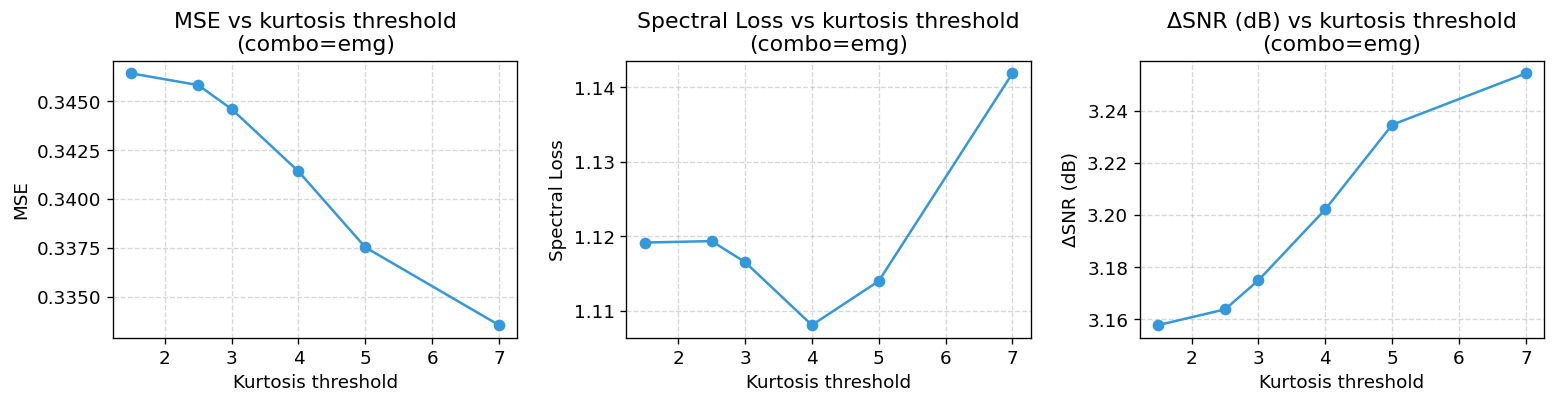

Saved -> ablation_kurtosis.png


In [25]:
ABLATION_COMBO  = 'emg'                          # change to any available combo
KURT_THRESHOLDS = [1.5, 2.5, 3.0, 4.0, 5.0, 7.0]
ABLATION_N      = 500                            # smaller set for speed

if ABLATION_COMBO in all_results:
    clean_ab = all_results[ABLATION_COMBO]['clean'][:ABLATION_N]
    noisy_ab = all_results[ABLATION_COMBO]['noisy'][:ABLATION_N]

    ablation_rows = []
    for kt in tqdm(KURT_THRESHOLDS, desc=f'Ablation kurtosis sweep ({ABLATION_COMBO})'):
        d   = ICADenoiser(n_components=N_COMPONENTS, kurtosis_thresh=kt)
        den = d.denoise_batch(noisy_ab, show_progress=False)
        ablation_rows.append({
            'kurtosis_thresh': kt,
            'mse'            : mse(clean_ab, den),
            'spectral_loss'  : spectral_loss(clean_ab, den),
            'snr_improvement': snr_improvement(clean_ab, noisy_ab, den),
        })

    df_abl = pd.DataFrame(ablation_rows)
    print(df_abl.to_string(index=False))

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
    for ax, col, title in zip(
        axes,
        ['mse', 'spectral_loss', 'snr_improvement'],
        ['MSE', 'Spectral Loss', 'ΔSNR (dB)']
    ):
        ax.plot(df_abl['kurtosis_thresh'], df_abl[col], 'o-', color='#3498db')
        ax.set_xlabel('Kurtosis threshold')
        ax.set_ylabel(title)
        ax.set_title(f'{title} vs kurtosis threshold\n(combo={ABLATION_COMBO})')
        ax.grid(True, ls='--', alpha=0.5)

    fig.tight_layout()
    fig.savefig(os.path.join(RESULTS_DIR, 'ablation_kurtosis.png'), bbox_inches='tight')
    plt.show()
    print('Saved -> ablation_kurtosis.png')
else:
    print(f'{ABLATION_COMBO} not in results. Change ABLATION_COMBO to an available combo.')

## 12 · Save Detailed Metrics CSV

In [26]:
detailed_rows = []
for combo, res in all_results.items():
    m   = res['metrics']
    row = {
        'combo'                  : combo,
        'mse_noisy'              : m['mse_noisy'],
        'mse_denoised'           : m['mse_denoised'],
        'rrmse_noisy'            : m['rrmse_noisy'],
        'rrmse_denoised'         : m['rrmse_denoised'],
        'snr_improvement_db'     : m['snr_improvement_db'],
        'spectral_loss_noisy'    : m['spectral_loss_noisy'],
        'spectral_loss_denoised' : m['spectral_loss_denoised'],
    }
    for band, val in m['band_spectral_loss'].items():
        row[f'band_{band}'] = val
    detailed_rows.append(row)

df_detail  = pd.DataFrame(detailed_rows)
out_path   = os.path.join(RESULTS_DIR, 'ica_detailed_metrics.csv')
df_detail.to_csv(out_path, index=False)
print(f'Saved -> {out_path}')
df_detail

Saved -> /kaggle/working/ica_results/ica_detailed_metrics.csv


,combo,mse_noisy,mse_denoised,rrmse_noisy,rrmse_denoised,snr_improvement_db,spectral_loss_noisy,spectral_loss_denoised,band_delta,band_theta,band_alpha,band_beta,band_gamma,band_high
0,emg,0.700111,0.350218,2.193147,1.329033,3.101951,3.306950,1.112117,999.808411,282.033447,912.546387,105.209450,25.550341,19.021011
1,eog,0.706871,0.823022,2.193147,2.252144,-0.932276,0.169677,0.780869,7330.948730,405.982086,896.450500,106.403633,22.958614,7.013869
2,ecg,1.469155,1.457920,2.193147,2.046369,-0.158477,0.318183,0.864717,1867.411133,574.178101,1442.143433,175.373505,35.611145,10.128196
3,emg_eog,0.808840,0.562283,3.092170,2.432005,1.494089,2.960833,1.065855,4669.256348,293.628021,550.290771,69.903069,19.481731,14.092037
4,emg_ecg,1.015806,0.630404,3.099481,2.272719,2.051594,3.222837,1.162174,1633.050903,313.016388,688.151794,83.042259,23.177301,17.735207
5,eog_ecg,1.033843,0.969304,3.094134,2.861255,0.202616,0.386462,0.829058,6006.809082,423.610565,691.412720,87.458488,21.502016,7.303433
6,emg_eog_ecg,0.999828,0.708669,3.777387,3.040012,1.475575,2.937773,1.133682,4634.784668,312.450958,469.661407,61.704411,18.600542,14.324446


In [1]:
!pwd

/kaggle/working


In [2]:
!zip -r ica_results.zip ica_results

  adding: ica_results/ (stored 0%)
  adding: ica_results/ablation_kurtosis.png (deflated 9%)
  adding: ica_results/example_emg_eog_ecg.png (deflated 2%)
  adding: ica_results/example_emg.png (deflated 2%)
  adding: ica_results/band_spectral_loss.png (deflated 20%)
  adding: ica_results/example_ecg.png (deflated 3%)
  adding: ica_results/spectral_snr_summary.png (deflated 17%)
  adding: ica_results/ica_summary.csv (deflated 45%)
  adding: ica_results/example_emg_eog.png (deflated 2%)
  adding: ica_results/ica_detailed_metrics.csv (deflated 47%)
  adding: ica_results/example_eog.png (deflated 3%)
  adding: ica_results/example_emg_ecg.png (deflated 2%)
  adding: ica_results/example_eog_ecg.png (deflated 3%)
